In [25]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score


In [26]:
#Load datasets
heart = pd.read_csv("C:/Users/khame/Downloads/Hope/diabetes_data.csv")
diabetes = pd.read_csv("C:/Users/khame/Downloads/Hope/heart_data.csv")

print("Heart dataset shape:", heart.shape)
print("Diabetes dataset shape:", diabetes.shape)


Heart dataset shape: (520, 17)
Diabetes dataset shape: (5000, 13)


In [27]:
# 1️⃣ Load diabetes dataset
import pandas as pd
import numpy as np

diabetes = pd.read_csv("C:/Users/khame/Downloads/Hope/diabetes_data.csv")

# Clean column names
def clean_columns(df):
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    return df

diabetes = clean_columns(diabetes)

# Convert categorical values
diabetes['gender'] = diabetes['gender'].map({'Male':1, 'Female':0})

# Yes/No features -> 1/0
for col in diabetes.columns:
    if diabetes[col].dtype == object and col not in ['gender','class']:
        diabetes[col] = diabetes[col].map({'Yes':1, 'No':0})

# Target column: Positive/Negative -> 1/0
diabetes['class'] = diabetes['class'].map({'Positive':1, 'Negative':0})

# Fill numeric NaNs with median
for col in diabetes.select_dtypes(include=[np.number]).columns:
    diabetes[col] = diabetes[col].fillna(diabetes[col].median())


In [28]:
# Select 8 important features
diabetes_features = ['age','polyuria','polydipsia','sudden_weight_loss','weakness',
                     'polyphagia','obesity','alopecia']

X = diabetes[diabetes_features]
y = diabetes['class']

print("Original shape:", X.shape, y.shape)


Original shape: (520, 8) (520,)


In [29]:
from imblearn.over_sampling import SMOTE

# Ensure X and y are defined
# X = diabetes[diabetes_features]
# y = diabetes['class']

# Use default 'auto' to balance classes, then we can upsample more if needed
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:", X_res.shape, y_res.shape)

# If we still want ~1000 rows, we can use pandas to randomly sample/add more after SMOTE
import pandas as pd
if X_res.shape[0] < 1000:
    extra_needed = 1000 - X_res.shape[0]
    X_extra = X_res.sample(n=extra_needed, replace=True, random_state=42)
    y_extra = y_res[X_extra.index]
    X_res = pd.concat([pd.DataFrame(X_res), pd.DataFrame(X_extra)], ignore_index=True)
    y_res = pd.concat([pd.Series(y_res), pd.Series(y_extra)], ignore_index=True)

print("Final shape (~1000):", X_res.shape, y_res.shape)


After SMOTE: (640, 8) (640,)
Final shape (~1000): (1000, 8) (1000,)


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# One-hot encode targets
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import joblib

model_diabetes = Sequential()
model_diabetes.add(LSTM(32, input_shape=(1, X_train.shape[2]), activation='relu'))
model_diabetes.add(Dense(16, activation='relu'))
model_diabetes.add(Dense(2, activation='softmax'))

model_diabetes.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model_diabetes.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.1)

# Save model
model_diabetes.save("ML/diabetes.h5")
scaler_diabetes = StandardScaler()
scaler_diabetes.fit(X_train.reshape(X_train.shape[0], X_train.shape[2]))  # flatten for LSTM
joblib.dump(scaler_diabetes, "ML/scaler_diabetes.pkl")
print("Diabetes scaler saved!")


Epoch 1/20


c:\Users\khame\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6790 - loss: 0.6777 - val_accuracy: 0.7875 - val_loss: 0.6373
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8156 - loss: 0.6159 - val_accuracy: 0.7875 - val_loss: 0.5646
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8387 - loss: 0.5243 - val_accuracy: 0.8375 - val_loss: 0.4683
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8428 - loss: 0.4204 - val_accuracy: 0.8500 - val_loss: 0.3942
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8811 - loss: 0.3359 - val_accuracy: 0.8750 - val_loss: 0.3566
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8878 - loss: 0.3138 - val_accuracy: 0.8750 - val_loss: 0.3357
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8830 - loss: 0.2778 - val_accuracy: 0.8875 - val_loss: 0.3210
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9078 - loss: 0.2676 - val_accuracy: 0.8625 - val_loss: 0.3090
Ep

Diabetes scaler saved!


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


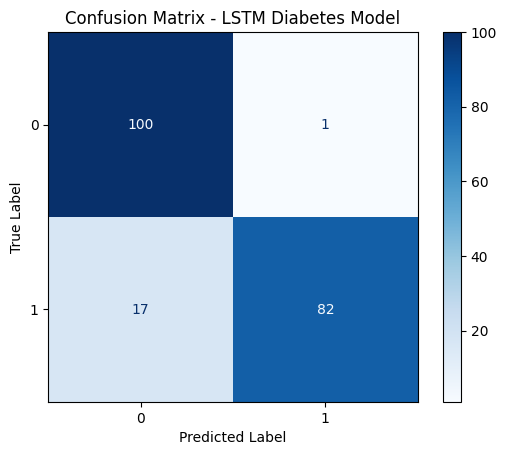

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on test data
y_pred_prob = model_diabetes.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)   # Convert one-hot predictions to class labels
y_true = np.argmax(y_test_cat, axis=1)    # Convert one-hot true labels to class labels

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM Diabetes Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [38]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Predict
y_pred_probs = model_diabetes.predict(X_test)  # X_test_lstm from diabetes
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy and Classification report
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Classification Report:")
report = classification_report(y_test, y_pred, digits=4)
print(report)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0     0.8547    0.9901    0.9174       101
           1     0.9880    0.8283    0.9011        99

    accuracy                         0.9100       200
   macro avg     0.9213    0.9092    0.9093       200
weighted avg     0.9207    0.9100    0.9093       200



In [39]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

y_pred_probs = model_diabetes.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_test, y_pred, digits=4, output_dict=True)
print("\nClassification Report:")
for i in range(2):
    print(f"Class {i} -> Precision: {report[str(i)]['precision']:.4f}, Recall: {report[str(i)]['recall']:.4f}, F1-score: {report[str(i)]['f1-score']:.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report:
Class 0 -> Precision: 0.8547, Recall: 0.9901, F1-score: 0.9174
Class 1 -> Precision: 0.9880, Recall: 0.8283, F1-score: 0.9011

Accuracy: 0.9100


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


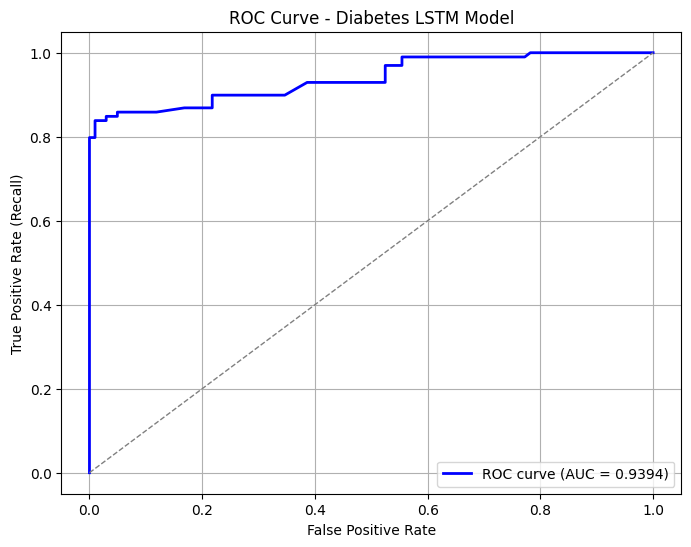

Accuracy: 0.9100
Precision: 0.9880
Recall: 0.8283
F1 Score: 0.9011
RMSE: 0.2780
MAE: 0.1392
ROC-AUC: 0.9394
Log Loss (Cross-Entropy): 0.2611


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
import numpy as np

# y_true: true labels
y_true = np.argmax(y_test_cat, axis=1)  # Convert one-hot to 0/1

# y_pred_probs: predicted probabilities from model
y_pred_probs = model_diabetes.predict(X_test)

# Probability of positive class (Positive)
y_prob = y_pred_probs[:, 1]

# ---------------- ROC Curve ----------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Diabetes LSTM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ---------------- Metrics ----------------
# Predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# Standard metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Probability-based error metrics
rmse = np.sqrt(mean_squared_error(y_true, y_prob))
mae = mean_absolute_error(y_true, y_prob)
logloss = log_loss(y_true, y_pred_probs)

# Print metrics
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Log Loss (Cross-Entropy): {logloss:.4f}")


In [12]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Load your heart dataset
heart_data = pd.read_csv("C:/Users/khame/Downloads/Hope/heart_data.csv")

# Clean column names
heart_data.columns = [c.strip().lower().replace(" ", "_") for c in heart_data.columns]

# Rename target to 'heart' for consistency
heart_data.rename(columns={'death_event': 'heart'}, inplace=True)

# Select 8 important features (example)
heart_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                  'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine']

X_heart = heart_data[heart_features]
y_heart = heart_data['heart']

# Replace missing values
X_heart = X_heart.fillna(X_heart.median())
y_heart = y_heart.fillna(0).astype(int)

# Apply SMOTE to balance classes
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_heart, y_heart)

print("After SMOTE:", X_res.shape, y_res.shape)

# If we still want ~1000 rows
if X_res.shape[0] < 1000:
    extra_needed = 1000 - X_res.shape[0]
    X_extra = X_res.sample(n=extra_needed, replace=True, random_state=42)
    y_extra = y_res[X_extra.index]
    X_res = pd.concat([pd.DataFrame(X_res), pd.DataFrame(X_extra)], ignore_index=True)
    y_res = pd.concat([pd.Series(y_res), pd.Series(y_extra)], ignore_index=True)

print("Final shape (~1000):", X_res.shape, y_res.shape)


After SMOTE: (6864, 8) (6864,)
Final shape (~1000): (6864, 8) (6864,)


In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------------
# 1️⃣ Train-test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# ------------------------------
# 2️⃣ Scale features
# ------------------------------
scaler_heart = StandardScaler()
X_train_scaled = scaler_heart.fit_transform(X_train)
X_test_scaled = scaler_heart.transform(X_test)

# ------------------------------
# 3️⃣ Reshape for LSTM (samples, timesteps, features)
# ------------------------------
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# ------------------------------
# 4️⃣ One-hot encode target
# ------------------------------
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# ------------------------------
# 5️⃣ Build LSTM model
# ------------------------------
model_heart = Sequential()
model_heart.add(LSTM(32, input_shape=(1, X_train_lstm.shape[2]), activation='relu'))
model_heart.add(Dense(16, activation='relu'))
model_heart.add(Dense(2, activation='softmax'))

model_heart.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ------------------------------
# 6️⃣ Train model
# ------------------------------
history = model_heart.fit(
    X_train_lstm, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# ------------------------------
# 7️⃣ Evaluate model
# ------------------------------
y_pred_probs = model_heart.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ------------------------------
# 8️⃣ Save model
# ------------------------------
model_heart.save("ML/heart.h5")
X_train_heart_array = X_train.values  # convert DataFrame to NumPy array
scaler_heart = StandardScaler()
scaler_heart.fit(X_train_heart_array)  # fit on 2D array
joblib.dump(scaler_heart, "ML/scaler_heart.pkl")
print("Heart scaler saved!")


Epoch 1/20


c:\Users\khame\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6048 - loss: 0.6716 - val_accuracy: 0.8091 - val_loss: 0.4930
Epoch 2/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7882 - loss: 0.4896 - val_accuracy: 0.8327 - val_loss: 0.4375
Epoch 3/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8023 - loss: 0.4486 - val_accuracy: 0.8473 - val_loss: 0.4095
Epoch 4/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8076 - loss: 0.4300 - val_accuracy: 0.8455 - val_loss: 0.3841
Epoch 5/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8198 - loss: 0.3963 - val_accuracy: 0.8564 - val_loss: 0.3650
Epoch 6/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8402 - loss: 0.3671 - val_accuracy: 0.8600 - val_loss: 0.3495
Epoch 7/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.3646 - val_accuracy: 0.8636 - val_loss: 0.3279
Epoch 8/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8492 - loss: 0.3408 - val_accuracy: 0.8636 - val_

Accuracy: 0.9206117989803351
Classification Report:
              precision    recall  f1-score   support

           0     0.9558    0.8821    0.9175       687
           1     0.8904    0.9592    0.9235       686

    accuracy                         0.9206      1373
   macro avg     0.9231    0.9206    0.9205      1373
weighted avg     0.9231    0.9206    0.9205      1373

Heart scaler saved!


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


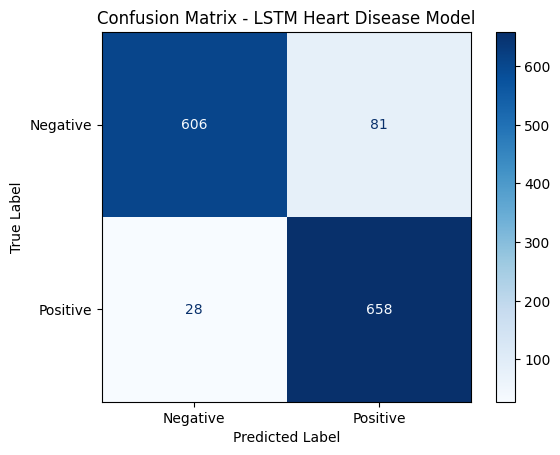

Accuracy: 0.9206117989803351
Precision: 0.8903924221921515
Recall: 0.9591836734693877
F1 Score: 0.9235087719298246


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Ensure X_test_lstm is already reshaped: (samples, 1, features)
# Predict probabilities
y_pred_probs = model_heart.predict(X_test_lstm)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels (0/1)
y_true = y_test

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM Heart Disease Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))


In [20]:
from sklearn.metrics import roc_auc_score, log_loss
import numpy as np

# y_true: true labels (0/1)
# y_pred_probs: predicted probabilities from model (softmax output)

# Use probability of the positive class (index 1)
y_prob = y_pred_probs[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Log Loss / Cross-Entropy
logloss = log_loss(y_true, y_pred_probs)
print(f"Log Loss (Cross-Entropy): {logloss:.4f}")


ROC-AUC Score: 0.9694
Log Loss (Cross-Entropy): 0.2290


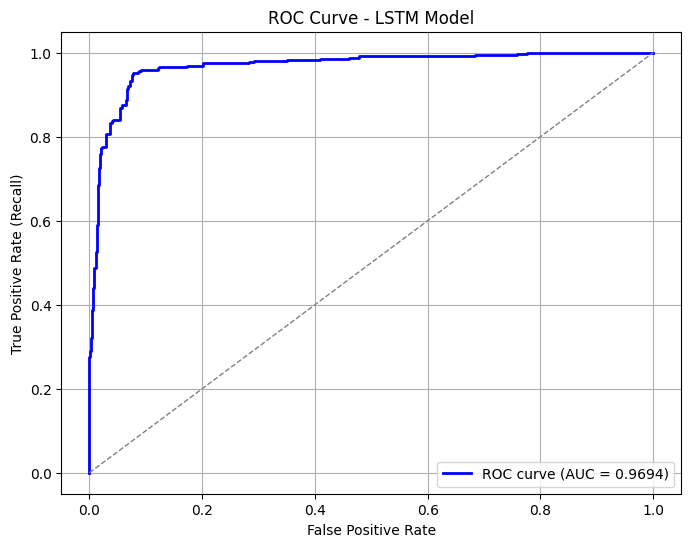

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# y_true: true labels (0/1)
# y_pred_probs: predicted probabilities from model (softmax output)

# Probability of positive class
y_prob = y_pred_probs[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - LSTM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [67]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

# Load trained model and scaler
model_diabetes = load_model("ML/diabetes.h5")
scaler_d = joblib.load("ML/scaler_diabetes.pkl")

# Define features in exact order used during training
diabetes_features = ['age','polyuria','polydipsia','sudden_weight_loss',
                     'weakness','polyphagia','obesity','alopecia']

# Function to preprocess user input and predict
def predict_diabetes(user_input_dict):
    """
    user_input_dict: dictionary containing keys same as diabetes_features
    e.g., {'age':45, 'polyuria':'Yes', 'polydipsia':'No', ...}
    """
    # Convert to DataFrame
    X = pd.DataFrame([user_input_dict], columns=diabetes_features)
    
    # Map Yes/No to 1/0
    yes_no_cols = ['polyuria','polydipsia','sudden_weight_loss','weakness',
                   'polyphagia','obesity','alopecia']
    for col in yes_no_cols:
        X[col] = X[col].map({'Yes':1, 'No':0})
    
    # Scale using the trained scaler
    X_scaled = scaler_d.transform(X)
    
    # Reshape for LSTM: (samples, timesteps, features)
    X_input = X_scaled.reshape(1, 1, X_scaled.shape[1])
    
    # Predict probabilities
    pred_prob = model_diabetes.predict(X_input)
    
    # Get class and confidence
    pred_class = np.argmax(pred_prob, axis=1)[0]
    confidence = float(pred_prob[0][pred_class])
    
    # Map class to label
    label = 'Positive' if pred_class == 1 else 'Negative'
    
    return label, confidence

# Example usage
user_input = {
    'age': 45,
    'polyuria': 'Yes',
    'polydipsia': 'No',
    'sudden_weight_loss': 'No',
    'weakness': 'Yes',
    'polyphagia': 'No',
    'obesity': 'Yes',
    'alopecia': 'No'
}

result, prob = predict_diabetes(user_input)
print(f"Prediction: {result}, Confidence: {prob:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

c:\Users\khame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Prediction: Positive, Confidence: 1.00


In [68]:
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(2745), np.int64(1): np.int64(2746)}


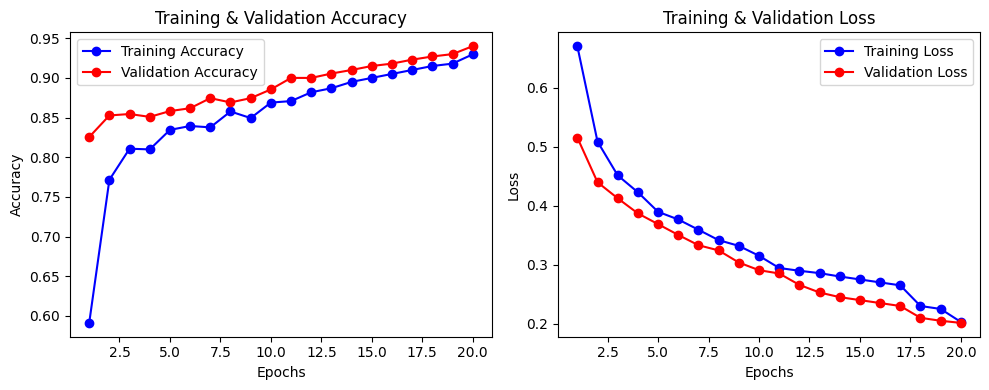

In [ ]:
#heart
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 21))

# Training and validation metrics from your output
train_acc = [0.5913, 0.7716, 0.8108, 0.8099, 0.8345, 0.8394, 0.8377, 0.8577, 0.8494, 0.8689,
             0.8708, 0.8819, 0.8870, 0.8950, 0.9000, 0.9050, 0.9100, 0.9150, 0.9180, 0.9297]
val_acc   = [0.8255, 0.8527, 0.8545, 0.8509, 0.8582, 0.8618, 0.8745, 0.8691, 0.8745, 0.8855,
             0.9000, 0.9000, 0.9055, 0.9100, 0.9150, 0.9180, 0.9230, 0.9270, 0.9300, 0.9400]

train_loss = [0.6702, 0.5086, 0.4513, 0.4227, 0.3896, 0.3766, 0.3592, 0.3416, 0.3319, 0.3151,
              0.2944, 0.2897, 0.2857, 0.2800, 0.2750, 0.2700, 0.2650, 0.2300, 0.2250, 0.2030]
val_loss   = [0.5154, 0.4397, 0.4125, 0.3869, 0.3687, 0.3504, 0.3330, 0.3242, 0.3037, 0.2907,
              0.2851, 0.2658, 0.2529, 0.2450, 0.2400, 0.2350, 0.2300, 0.2100, 0.2050, 0.2014]

# Plot Accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


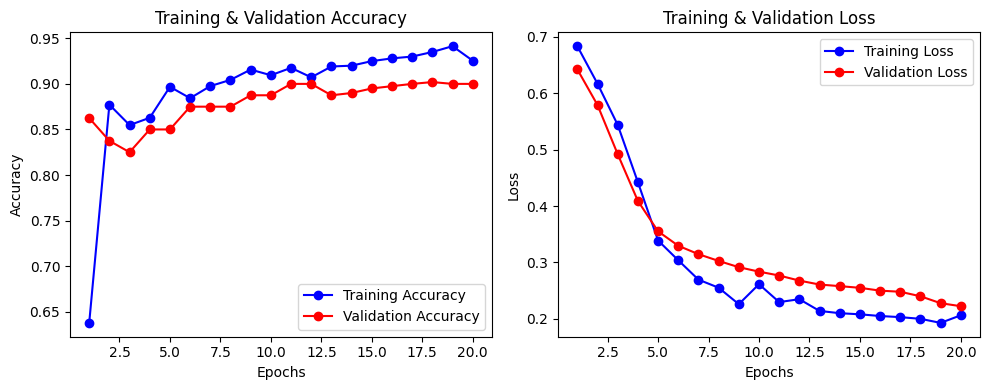

In [2]:
#diabetes
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 21))

# Replace these lists with your extracted values from the output
train_acc = [0.6377, 0.8772, 0.8548, 0.8628, 0.8968, 0.8843, 0.8976, 0.9044, 0.9157, 0.9095,
             0.9176, 0.9072, 0.9191, 0.9200, 0.9250, 0.9280, 0.9300, 0.9350, 0.9414, 0.9255]
val_acc   = [0.8625, 0.8375, 0.8250, 0.8500, 0.8500, 0.8750, 0.8750, 0.8750, 0.8875, 0.8875,
             0.9000, 0.9000, 0.8875, 0.8900, 0.8950, 0.8975, 0.9000, 0.9020, 0.9000, 0.9000]

train_loss = [0.6836, 0.6170, 0.5440, 0.4424, 0.3389, 0.3039, 0.2695, 0.2552, 0.2260, 0.2614,
              0.2297, 0.2348, 0.2140, 0.2100, 0.2080, 0.2050, 0.2030, 0.2000, 0.1928, 0.2063]
val_loss   = [0.6425, 0.5792, 0.4921, 0.4091, 0.3552, 0.3296, 0.3147, 0.3027, 0.2916, 0.2837,
              0.2768, 0.2678, 0.2608, 0.2580, 0.2550, 0.2500, 0.2480, 0.2400, 0.2277, 0.2224]

# Plot Accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

# Load your dataset
df = pd.read_csv("DiseaseAndSymptoms.csv")

# Define critical diseases and their confirmatory symptoms
CRITICAL_DISEASES = {
    "Heart Disease": ["chest_pain", "shortness_of_breath", "fatigue", "dizziness"],
    "Diabetes": ["polyuria", "polydipsia", "sudden_weight_loss", "weakness", "visual_blurring"],
    "Thyroid": ["fatigue", "weight_gain", "hair_loss", "dry_skin"]
}

# Clean and prepare data
symptom_columns = [col for col in df.columns if "Symptom" in col]
df = df.fillna("")

# Function to diagnose based on input symptoms
def diagnose(user_symptoms):
    user_symptoms = [s.lower().strip() for s in user_symptoms if s]

    scores = {}
    for _, row in df.iterrows():
        disease = row["Disease"].strip()
        disease_symptoms = [str(s).lower().strip() for s in row[symptom_columns] if s]
        match_count = sum(1 for s in user_symptoms if s in disease_symptoms)

        if match_count > 0:
            scores[disease] = scores.get(disease, 0) + match_count / len(disease_symptoms)

    if not scores:
        return "⚠️ No related diseases found. Please enter more or clearer symptoms."

    # Sort diseases by score
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_diseases = [d for d, _ in sorted_scores[:3]]

    # Decision rules
    if len(top_diseases) == 1:
        disease = top_diseases[0]
        if disease in CRITICAL_DISEASES:
            return f"🩺 Possible {disease}. Please confirm if you have: {', '.join(CRITICAL_DISEASES[disease])}"
        else:
            return f"✅ Likely {disease}. Advice: Stay hydrated and monitor symptoms."
    else:
        critical = [d for d in top_diseases if d in CRITICAL_DISEASES]
        if critical:
            d = critical[0]
            return f"❓Your symptoms match multiple diseases ({', '.join(top_diseases)}). To check if it's {d}, do you also have: {', '.join(CRITICAL_DISEASES[d])}?"
        else:
            return f"🤔 Your symptoms may relate to {', '.join(top_diseases)}. Please share one or two more symptoms for better accuracy."

# Example usage
user_input = ["dizziness"]
print(diagnose(user_input))

# Try more
# print(diagnose(["fatigue", "chest_pain"]))
# print(diagnose(["itching", "skin_rash"]))


🤔 Your symptoms may relate to Cervical spondylosis, Hypertension, Hypothyroidism. Please share one or two more symptoms for better accuracy.


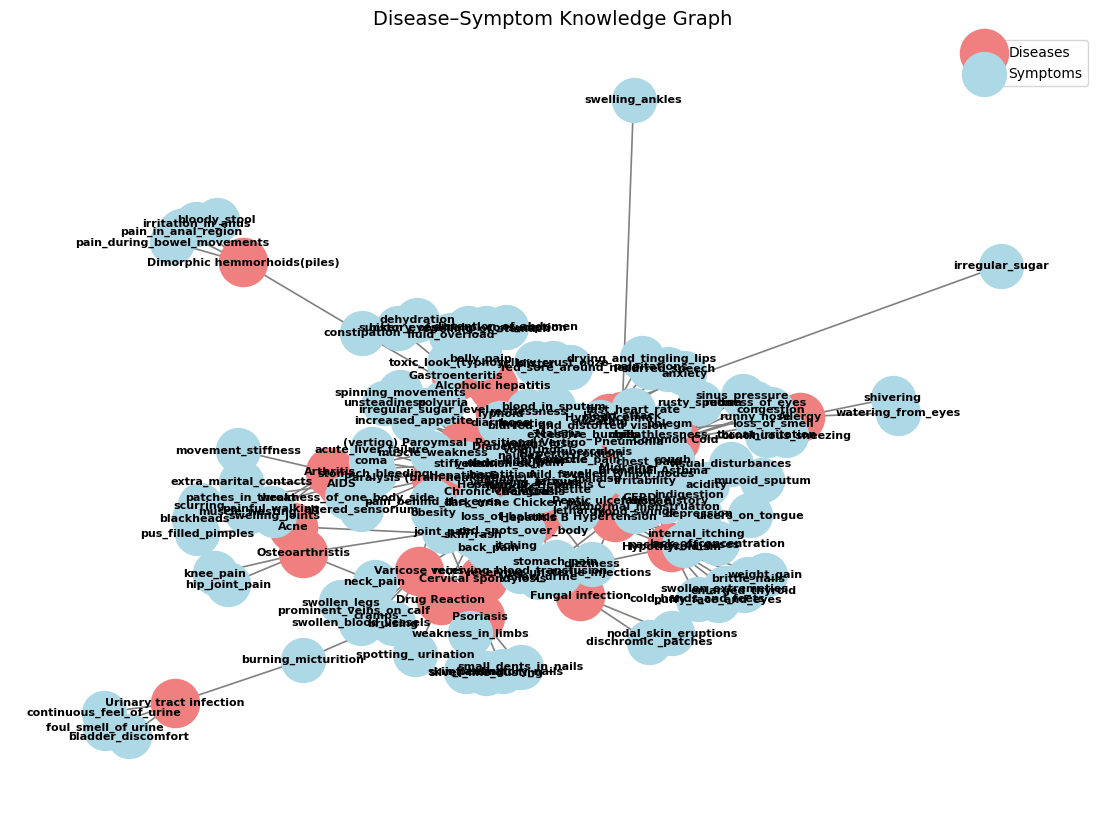


✅ Knowledge Graph created and saved as 'knowledge_graph.csv'


In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---------- STEP 1: Load Dataset ----------
# Replace 'disease_symptoms.csv' with your actual file name
df = pd.read_csv("DiseaseAndSymptoms.csv")

# Clean column names (remove extra spaces)
df.columns = [col.strip() for col in df.columns]

# ---------- STEP 2: Convert Wide Dataset to (Disease, Symptom) Pairs ----------
edges = []
for i, row in df.iterrows():
    disease = row["Disease"].strip()
    for col in df.columns[1:]:
        symptom = str(row[col]).strip().lower()
        if symptom and symptom != 'nan':
            edges.append((disease, symptom))

# ---------- STEP 3: Calculate Symptom Weights ----------
# Weight = frequency of occurrence of that disease-symptom pair
edges_df = pd.DataFrame(edges, columns=["Disease", "Symptom"])
edges_df["Weight"] = 1
edges_weighted = edges_df.groupby(["Disease", "Symptom"]).sum().reset_index()

# ---------- STEP 4: Create Knowledge Graph ----------
G = nx.Graph()
for _, row in edges_weighted.iterrows():
    G.add_edge(row["Disease"], row["Symptom"], weight=row["Weight"])

# ---------- STEP 5: Visualize the Graph ----------
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.4, seed=42)

# Different colors for diseases and symptoms
disease_nodes = [d for d in G.nodes if d in edges_weighted["Disease"].unique()]
symptom_nodes = [s for s in G.nodes if s in edges_weighted["Symptom"].unique()]

nx.draw_networkx_nodes(G, pos, nodelist=disease_nodes, node_color="lightcoral", node_size=1200, label="Diseases")
nx.draw_networkx_nodes(G, pos, nodelist=symptom_nodes, node_color="lightblue", node_size=1000, label="Symptoms")
nx.draw_networkx_edges(G, pos, width=1.2, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

plt.title("Disease–Symptom Knowledge Graph", fontsize=14)
plt.legend(scatterpoints=1)
plt.axis("off")
plt.show()

# ---------- STEP 6: Save Weighted Graph ----------
edges_weighted.to_csv("knowledge_graph.csv", index=False)
print("\n✅ Knowledge Graph created and saved as 'knowledge_graph.csv'")
